
 >>> BEST STRATEGY: Strategy D (TQQQ + RSI/MACD) <<<



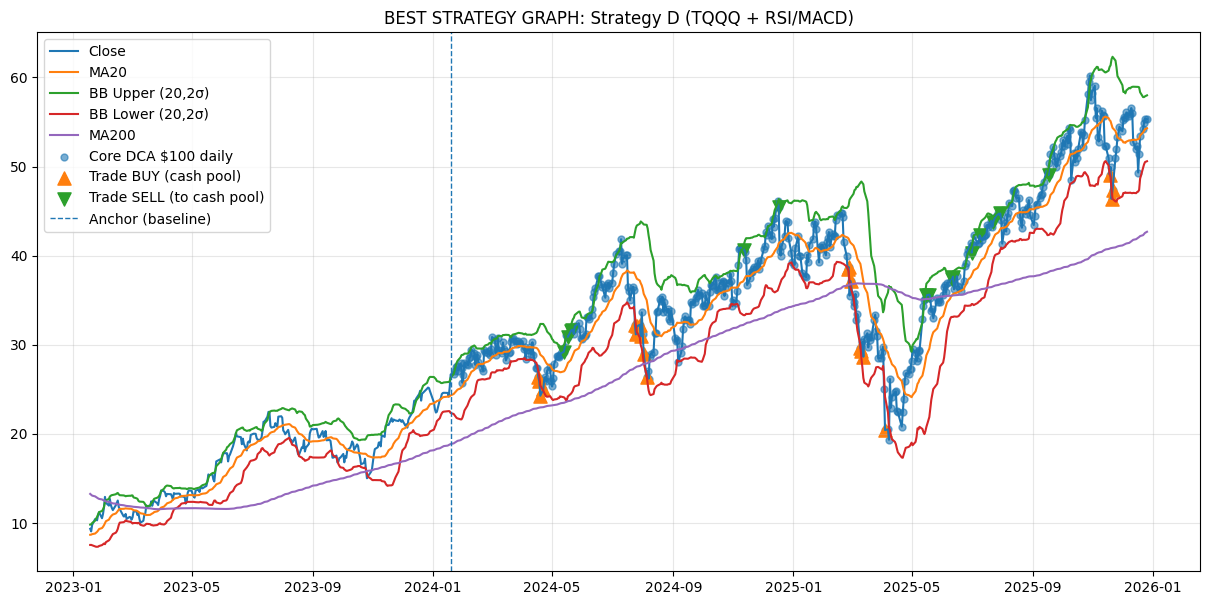


 [JUDGEMENT] Reasoning for Best Strategy
Selected Strategy: Strategy D (TQQQ + RSI/MACD)
Reason: Highest Final Total Equity at end of simulation
Final Equity: $14,434.22

 [SUMMARY] Best Strategy Action Guide
Date: 2025-12-26
Close: 55.31 (SignalZ: 0.55)
Holdings: Core=103.19 shares, Trade=130.24 shares
Cash Pool: $1,523.53
👉 ACTION: HOLD / DCA Only

 [COMPARISON] Return Comparison vs Best
STRATEGY                            | FINAL EQUITY    | DIFF (vs BEST) 
---------------------------------------------------------------------------
* Strategy D (TQQQ + RSI/MACD)      | $14,434        | $0 (0.0%)
  Strategy C (QQQ + RSI/MACD)       | $14,160        | $-274 (-1.9%)
  Strategy A (TQQQ Judge)           | $13,929        | $-506 (-3.5%)
  Strategy B (QQQ Judge)            | $13,814        | $-621 (-4.3%)
---------------------------------------------------------------------------
* Indicates the best strategy.


In [2]:
# Equivalent to "%matplotlib inline" in Jupyter
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# Settings (Kept Original)
# =========================
TICKER = "TQQQ"          # Execution/Evaluation/Core DCA Ticker
SIGNAL_TICKER = "QQQ"    # Trend Judgment Ticker

# Indicators
BB_WINDOW = 20
BB_K = 2.0
MA200_W = 200

# Signal Criteria
ADD_BUY_Z = -1.5
SELL_Z1   =  1.5
SELL_Z2   =  2.0

# Strategy C/D Additional Signal Criteria
RSI_PERIOD = 14
RSI_BUY_NORMAL = 40.0
RSI_BUY_CRASH  = 30.0
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9

# Capital/Trading Settings
DCA_DOLLARS_PER_DAY = 7.0
SELL1_FRACTION = 0.25
SELL2_FRACTION = 0.50
TRADE_BUY_USE_FRACTION = 0.40
MIN_TRADE_BUY_DOLLARS = 50.0

# Data
PERIOD = "5y"
INTERVAL = "1d"
START_DATE = "2024-01-19"

INITIAL_EQUITY = 223.57
INITIAL_TRADE_CASH = 5000.0
INITIAL_TRADE_SHARES = 0.0

LOOKBACK_BARS = 252

# =========================
# Utility Functions
# =========================
def _download_ohlc(ticker: str) -> pd.DataFrame:
    df = yf.download(ticker, period=PERIOD, interval=INTERVAL, auto_adjust=True, group_by="column", progress=False).dropna()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def _calc_rsi(close: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    close = close.astype(float)
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)
    avg_gain = gain.ewm(alpha=1.0/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1.0/period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi.fillna(100.0)

def _add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    close = df["Close"].astype(float)
    df["MA20"]  = close.rolling(BB_WINDOW).mean()
    df["STD20"] = close.rolling(BB_WINDOW).std(ddof=0)
    df["Upper"] = df["MA20"] + BB_K * df["STD20"]
    df["Lower"] = df["MA20"] - BB_K * df["STD20"]
    df["MA200"] = close.rolling(MA200_W).mean()
    df["Z"]     = (close - df["MA20"]) / df["STD20"]
    df["RSI"]   = _calc_rsi(close, RSI_PERIOD)
    
    ema_fast = close.ewm(span=MACD_FAST, adjust=False).mean()
    ema_slow = close.ewm(span=MACD_SLOW, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=MACD_SIGNAL, adjust=False).mean()
    df["MACD"] = macd
    df["MACDSignal"] = macd_signal
    df["MACDHist"] = macd - macd_signal
    
    return df.dropna()

def _pick_anchor_date(df: pd.DataFrame, start_date: str) -> pd.Timestamp:
    start_ts = pd.Timestamp(start_date)
    df_before = df[df.index <= start_ts]
    if df_before.empty: raise ValueError("No data before/on START_DATE")
    return df_before.index[-1]

def _nearest_or_on(df: pd.DataFrame, target_dt: pd.Timestamp) -> pd.Timestamp:
    idx = df.index.get_indexer([target_dt], method="pad")
    if idx[0] == -1: raise ValueError("No data before/on target date")
    return df.index[idx[0]]

def _simulate(exec_df, signal_df, anchor_dt, anchor_price, initial_equity, initial_trade_cash, initial_trade_shares, use_signal_ticker_for_judgement, signal_rule="BASE"):
    df_sim = exec_df[exec_df.index >= anchor_dt].copy()
    sig_aligned = signal_df.reindex(df_sim.index).ffill()

    if use_signal_ticker_for_judgement:
        df_sim["SIG_Close"] = sig_aligned["Close"].astype(float)
        df_sim["SIG_MA200"] = sig_aligned["MA200"].astype(float)
        df_sim["SIG_Z"]     = sig_aligned["Z"].astype(float)
        df_sim["SIG_RSI"]   = sig_aligned["RSI"].astype(float)
        df_sim["SIG_MACDH"] = sig_aligned["MACDHist"].astype(float)
    else:
        df_sim["SIG_Close"] = df_sim["Close"].astype(float)
        df_sim["SIG_MA200"] = df_sim["MA200"].astype(float)
        df_sim["SIG_Z"]     = df_sim["Z"].astype(float)
        df_sim["SIG_RSI"]   = df_sim["RSI"].astype(float)
        df_sim["SIG_MACDH"] = df_sim["MACDHist"].astype(float)

    trend_up = df_sim["SIG_Close"] > df_sim["SIG_MA200"]

    if signal_rule == "BASE":
        df_sim["ADD_BUY"] = trend_up & (df_sim["SIG_Z"] <= ADD_BUY_Z)
        df_sim["SELL_1"]  = trend_up & (df_sim["SIG_Z"] >= SELL_Z1)
        df_sim["SELL_2"]  = trend_up & (df_sim["SIG_Z"] >= SELL_Z2)
    elif signal_rule == "C":
        buy_z = df_sim["SIG_Z"] <= ADD_BUY_Z
        buy_normal = trend_up & (df_sim["SIG_RSI"] < RSI_BUY_NORMAL)
        buy_crash = (df_sim["SIG_RSI"] < RSI_BUY_CRASH)
        df_sim["ADD_BUY"] = buy_z & (buy_normal | buy_crash)
        macd_hist_dec = df_sim["SIG_MACDH"].diff() < 0
        df_sim["SELL_1"] = trend_up & (df_sim["SIG_Z"] >= SELL_Z1) & macd_hist_dec
        df_sim["SELL_2"] = trend_up & (df_sim["SIG_Z"] >= SELL_Z2) & macd_hist_dec
    
    core_shares = initial_equity / anchor_price
    trade_shares = float(initial_trade_shares)
    trade_cash = float(initial_trade_cash)
    records = []

    for i, (dt, row) in enumerate(df_sim.iterrows()):
        price = float(row["Close"])
        core_buy_shares = 0.0
        if i > 0:
            core_buy_shares = DCA_DOLLARS_PER_DAY / price
            core_shares += core_buy_shares
        
        did_trade_sell_shares = 0.0
        did_trade_sell_dollars = 0.0
        if bool(row["SELL_2"]) and trade_shares > 0:
            sell_shares = min(trade_shares, trade_shares * SELL2_FRACTION)
            trade_shares -= sell_shares
            proceeds = sell_shares * price
            trade_cash += proceeds
            did_trade_sell_shares, did_trade_sell_dollars = sell_shares, proceeds
        elif bool(row["SELL_1"]) and trade_shares > 0:
            sell_shares = min(trade_shares, trade_shares * SELL1_FRACTION)
            trade_shares -= sell_shares
            proceeds = sell_shares * price
            trade_cash += proceeds
            did_trade_sell_shares, did_trade_sell_dollars = sell_shares, proceeds
        
        did_trade_buy_shares = 0.0
        did_trade_buy_dollars = 0.0
        if bool(row["ADD_BUY"]) and trade_cash >= MIN_TRADE_BUY_DOLLARS:
            spend = trade_cash * TRADE_BUY_USE_FRACTION
            if spend >= MIN_TRADE_BUY_DOLLARS:
                buy_shares = spend / price
                trade_shares += buy_shares
                trade_cash -= spend
                did_trade_buy_shares, did_trade_buy_dollars = buy_shares, spend

        total_value = (core_shares * price) + (trade_shares * price) + trade_cash
        records.append({
            "Date": dt, "Close": price, "Z": float(row["Z"]),
            "SignalClose": float(row["SIG_Close"]), "SignalZ": float(row["SIG_Z"]),
            "SignalRSI": float(row["SIG_RSI"]), "SignalMACDHist": float(row["SIG_MACDH"]),
            "CoreShares": core_shares, "TradeShares": trade_shares, "TradeCash": trade_cash,
            "TotalValue": total_value, "CoreBuyShares": core_buy_shares,
            "TradeBuyDollars": did_trade_buy_dollars, "TradeSellDollars": did_trade_sell_dollars,
            "Signal_ADD_BUY": bool(row["ADD_BUY"]), "Signal_SELL_1": bool(row["SELL_1"]), "Signal_SELL_2": bool(row["SELL_2"])
        })
    return df_sim, pd.DataFrame(records).set_index("Date")

def _plot_price_with_signals(plot_df, bt, anchor_dt, title):
    dca_pts = bt[bt["CoreBuyShares"] > 0]
    trade_buys = bt[bt["TradeBuyDollars"] > 0]
    trade_sells = bt[bt["TradeSellDollars"] > 0]
    y_close = plot_df["Close"].reindex(bt.index)
    dca_y = y_close.reindex(dca_pts.index)
    buy_y = y_close.reindex(trade_buys.index)
    sell_y = y_close.reindex(trade_sells.index)
    
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(plot_df.index, plot_df["Close"], label="Close")
    ax.plot(plot_df.index, plot_df["MA20"], label="MA20")
    ax.plot(plot_df.index, plot_df["Upper"], label="BB Upper (20,2σ)")
    ax.plot(plot_df.index, plot_df["Lower"], label="BB Lower (20,2σ)")
    ax.plot(plot_df.index, plot_df["MA200"], label="MA200")
    
    ax.scatter(dca_pts.index, dca_y, marker="o", s=25, alpha=0.6, label="Core DCA $100 daily")
    ax.scatter(trade_buys.index, buy_y, marker="^", s=90, label="Trade BUY (cash pool)")
    ax.scatter(trade_sells.index, sell_y, marker="v", s=90, label="Trade SELL (to cash pool)")
    ax.axvline(anchor_dt, linestyle="--", linewidth=1, label="Anchor (baseline)")
    
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# =========================
# Main Execution
# =========================
# 1. Load Data
df = _download_ohlc(TICKER)
df = _add_indicators(df)
df_sig = _download_ohlc(SIGNAL_TICKER)
df_sig = _add_indicators(df_sig)

anchor_dt = _pick_anchor_date(df, START_DATE)
anchor_price = float(df.loc[anchor_dt, "Close"])
anchor_dt_sig = _nearest_or_on(df_sig, anchor_dt)

# Prepare Plot Data
anchor_pos = df.index.get_loc(anchor_dt)
df_plot_A = df.iloc[max(0, anchor_pos - LOOKBACK_BARS):].copy()

anchor_pos_sig = df_sig.index.get_loc(anchor_dt_sig)
df_plot_sig = df_sig.iloc[max(0, anchor_pos_sig - LOOKBACK_BARS):].copy()

# 2. Run Simulations for All Strategies
strategies = []

# (A) Strategy A
_, bt_A = _simulate(df, df, anchor_dt, anchor_price, INITIAL_EQUITY, INITIAL_TRADE_CASH, INITIAL_TRADE_SHARES, False, "BASE")
strategies.append({"name": "Strategy A (TQQQ Judge)", "bt": bt_A, "plot_df": df_plot_A, "anchor": anchor_dt})

# (B) Strategy B
_, bt_B = _simulate(df, df_sig, anchor_dt, anchor_price, INITIAL_EQUITY, INITIAL_TRADE_CASH, INITIAL_TRADE_SHARES, True, "BASE")
strategies.append({"name": "Strategy B (QQQ Judge)", "bt": bt_B, "plot_df": df_plot_sig, "anchor": anchor_dt_sig})

# (C) Strategy C
_, bt_C = _simulate(df, df_sig, anchor_dt, anchor_price, INITIAL_EQUITY, INITIAL_TRADE_CASH, INITIAL_TRADE_SHARES, True, "C")
strategies.append({"name": "Strategy C (QQQ + RSI/MACD)", "bt": bt_C, "plot_df": df_plot_sig, "anchor": anchor_dt_sig})

# (D) Strategy D
_, bt_D = _simulate(df, df, anchor_dt, anchor_price, INITIAL_EQUITY, INITIAL_TRADE_CASH, INITIAL_TRADE_SHARES, False, "C")
strategies.append({"name": "Strategy D (TQQQ + RSI/MACD)", "bt": bt_D, "plot_df": df_plot_A, "anchor": anchor_dt})

# 3. Determine Best Strategy (Highest Final Equity)
best_strategy = max(strategies, key=lambda x: x["bt"]["TotalValue"].iloc[-1])
best_bt = best_strategy["bt"]

# =========================
# [Output 1] Graph of the Best Strategy
# =========================
print(f"\n{'='*60}")
print(f" >>> BEST STRATEGY: {best_strategy['name']} <<<")
print(f"{'='*60}\n")

_plot_price_with_signals(
    best_strategy["plot_df"], 
    best_bt, 
    best_strategy["anchor"], 
    title=f"BEST STRATEGY GRAPH: {best_strategy['name']}"
)

# =========================
# [Output 2] Judgment (Reasoning)
# =========================
print(f"\n{'='*60}")
print(" [JUDGEMENT] Reasoning for Best Strategy")
print(f"{'='*60}")
print(f"Selected Strategy: {best_strategy['name']}")
print(f"Reason: Highest Final Total Equity at end of simulation")
print(f"Final Equity: ${best_bt['TotalValue'].iloc[-1]:,.2f}")

# =========================
# [Output 3] Summary (Action Guide)
# =========================
last_idx = best_bt.index[-1]
last_bt_row = best_bt.iloc[-1]
print(f"\n{'='*60}")
print(" [SUMMARY] Best Strategy Action Guide")
print(f"{'='*60}")
print(f"Date: {last_idx.date()}")
print(f"Close: {last_bt_row['Close']:.2f} (SignalZ: {last_bt_row['SignalZ']:.2f})")
print(f"Holdings: Core={last_bt_row['CoreShares']:.2f} shares, Trade={last_bt_row['TradeShares']:.2f} shares")
print(f"Cash Pool: ${last_bt_row['TradeCash']:,.2f}")

action_msg = "HOLD / DCA Only"
if last_bt_row['Signal_SELL_2'] and last_bt_row['TradeShares'] > 0:
    action_msg = "SELL STRONG (Signal Z >= 2.0)"
elif last_bt_row['Signal_SELL_1'] and last_bt_row['TradeShares'] > 0:
    action_msg = "SELL (Signal Z >= 1.5)"
elif last_bt_row['Signal_ADD_BUY'] and last_bt_row['TradeCash'] >= MIN_TRADE_BUY_DOLLARS:
    action_msg = "BUY (Dip Buying)"
print(f"👉 ACTION: {action_msg}")


# =========================
# [Output 4] Return Comparison (Best vs Others)
# =========================
print(f"\n{'='*60}")
print(" [COMPARISON] Return Comparison vs Best")
print(f"{'='*60}")
print(f"{'STRATEGY':<35} | {'FINAL EQUITY':<15} | {'DIFF (vs BEST)':<15}")
print("-" * 75)

best_val = best_bt["TotalValue"].iloc[-1]
all_strategies = sorted(strategies, key=lambda x: x["bt"]["TotalValue"].iloc[-1], reverse=True)

for s in all_strategies:
    val = s["bt"]["TotalValue"].iloc[-1]
    diff = val - best_val
    mark = "*" if s["name"] == best_strategy["name"] else ""
    print(f"{mark:<2}{s['name']:<33} | ${val:,.0f}        | ${diff:,.0f} ({diff/best_val*100:.1f}%)")

print("-" * 75)
print("* Indicates the best strategy.")
print("=" * 60)

▶ 분석 대상: ['QQQM', 'AVGO', 'MAGS', 'GOOGL', 'XLV', 'TQQQ', 'XLF', 'XLU', 'QLD', 'NVDA']
▶ 데이터 다운로드 중... (기간: 2024-04-01)
▶ 실제 시뮬레이션 기간: 2024-04-01 ~ 2025-12-26
▶ 총 거래일수: 438일

=== 📊 최종 성과 비교 ===
총 투자원금: $27,594.00
       Strategy  Final($)  Profit($)  ROI(%)
2      DCA_TQQQ 41,379.88  13,785.88   49.96
0  My_Portfolio 39,088.70  11,494.70   41.66
3       DCA_QLD 38,050.58  10,456.58   37.89
4      DCA_MAGS 37,121.27   9,527.27   34.53
1      DCA_QQQM 33,900.21   6,306.21   22.85


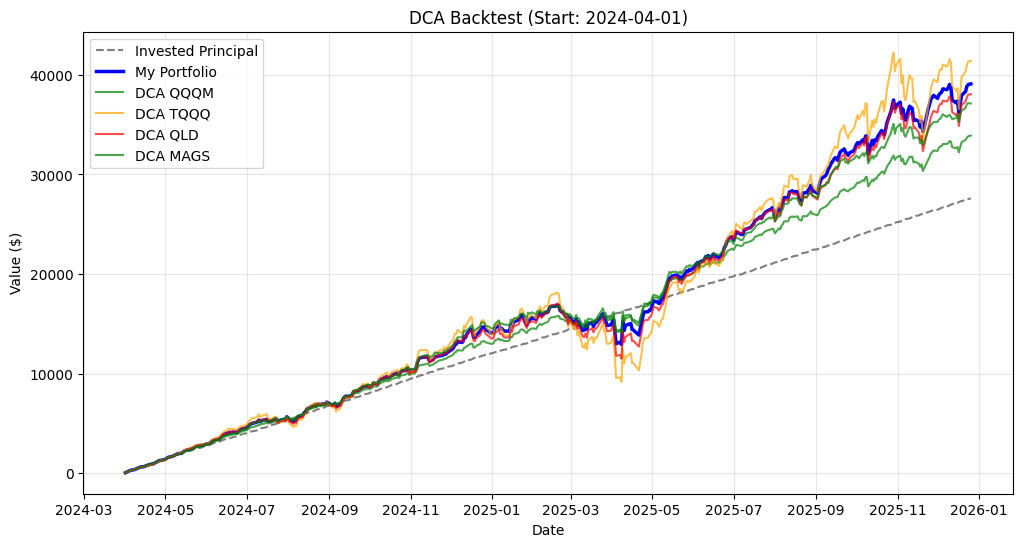

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ==========================================
# 1. 사용자 설정 (이곳을 자유롭게 수정하세요)
# ==========================================
# [설정 1] 포트폴리오 비중 (종목:비중)
USER_PORTFOLIO = "MAGS:15 / AVGO: 4 / GOOGL:4.5 / QLD: 14 / TQQQ: 7 / XLV: 3 / XLF: 1.5 / XLU: 1.5 / NVDA:3" 

# [설정 2] 비교할 벤치마크 (각각 100% 몰빵 시)
BENCHMARKS = ["QQQM", "TQQQ","QLD","MAGS"]

# [설정 3] 매일 투자할 금액 ($)
DAILY_INVESTMENT = 63.0 

# [설정 4] 백테스팅 시작 날짜 (YYYY-MM-DD 형식)
# None으로 두면 데이터가 가능한 가장 옛날부터 시작
START_DATE = "2024-04-01" 
# START_DATE = None 

# ==========================================
# 2. 데이터 다운로드 및 기간 필터링
# ==========================================
def parse_portfolio(input_str):
    portfolio_map = {}
    parts = input_str.split("/")
    total_weight = 0
    
    for part in parts:
        if ":" not in part: continue
        ticker, weight = part.split(":")
        portfolio_map[ticker.strip().upper()] = float(weight.strip())
        total_weight += float(weight.strip())
    
    return {k: v / total_weight for k, v in portfolio_map.items()}, list(portfolio_map.keys())

# 비중 파싱
my_ratios, my_tickers = parse_portfolio(USER_PORTFOLIO)
all_tickers = list(set(my_tickers + BENCHMARKS))

print(f"▶ 분석 대상: {all_tickers}")
print(f"▶ 데이터 다운로드 중... (기간: {START_DATE if START_DATE else 'Max'})")

# 데이터 다운로드
df = yf.download(all_tickers, period="10y", progress=False, auto_adjust=True)

# 종가(Close)만 추출
if isinstance(df.columns, pd.MultiIndex):
    try:
        df_close = df["Close"].copy()
    except KeyError:
        df_close = df.copy()
else:
    df_close = df["Close"].copy()

# [중요] 날짜 필터링 로직
# 1. 사용자가 지정한 START_DATE 이후 데이터만 남김
if START_DATE:
    df_close = df_close[df_close.index >= pd.Timestamp(START_DATE)]

# 2. 모든 종목의 데이터가 존재하는 구간만 남김 (NaN 제거)
# (예: 사용자가 2020년을 원해도 MAGS가 2023년에 상장했으면 2023년부터 시작)
df_close = df_close.dropna()

if df_close.empty:
    print("❌ 오류: 지정한 날짜 이후에 데이터가 없거나, 공통된 거래 기간이 없습니다.")
    exit()

print(f"▶ 실제 시뮬레이션 기간: {df_close.index[0].date()} ~ {df_close.index[-1].date()}")
print(f"▶ 총 거래일수: {len(df_close)}일")

# ==========================================
# 3. DCA(적립식 투자) 시뮬레이션
# ==========================================
results = pd.DataFrame(index=df_close.index)

# 누적 투자 원금 (매일 $100씩 증가)
results["Invested_Capital"] = range(1, len(results) + 1)
results["Invested_Capital"] *= DAILY_INVESTMENT

# (A) 내 포트폴리오 시뮬레이션
my_port_value = pd.Series(0.0, index=df_close.index)
for ticker, ratio in my_ratios.items():
    # 해당 종목에 할당된 매일 투자금
    daily_alloc = DAILY_INVESTMENT * ratio
    # 해당 종목의 누적 주식수 계산
    cum_shares = (daily_alloc / df_close[ticker]).cumsum()
    # 평가금액 합산
    my_port_value += cum_shares * df_close[ticker]

results["My_Portfolio"] = my_port_value

# (B) 벤치마크 시뮬레이션
for bench in BENCHMARKS:
    cum_shares = (DAILY_INVESTMENT / df_close[bench]).cumsum()
    results[f"DCA_{bench}"] = cum_shares * df_close[bench]

# ==========================================
# 4. 결과 리포트 및 시각화
# ==========================================
final_val = results.iloc[-1]
invested = final_val["Invested_Capital"]

# 요약표 생성
summary = []
cols = ["My_Portfolio"] + [f"DCA_{b}" for b in BENCHMARKS]

for col in cols:
    val = final_val[col]
    profit = val - invested
    roi = (profit / invested) * 100
    summary.append({"Strategy": col, "Final($)": val, "Profit($)": profit, "ROI(%)": roi})

df_summary = pd.DataFrame(summary).sort_values("Final($)", ascending=False)
pd.options.display.float_format = '{:,.2f}'.format

print("\n=== 📊 최종 성과 비교 ===")
print(f"총 투자원금: ${invested:,.2f}")
print(df_summary)

# 그래프
plt.figure(figsize=(12, 6))
plt.plot(results.index, results["Invested_Capital"], 'k--', label="Invested Principal", alpha=0.5)
plt.plot(results.index, results["My_Portfolio"], label="My Portfolio", linewidth=2.5, color='blue')

colors = ['green', 'orange', 'red']
for i, bench in enumerate(BENCHMARKS):
    plt.plot(results.index, results[f"DCA_{bench}"], label=f"DCA {bench}", color=colors[i % len(colors)], alpha=0.7)

plt.title(f"DCA Backtest (Start: {df_close.index[0].date()})")
plt.xlabel("Date")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()